# Week 3 · XGBoost Model
Business Rehearsal Outcome Predictor · Spring 2026

XGBoost with quantile regression for calibrated 80% prediction intervals.
Directly comparable to the baseline — same split, same metrics.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.figsize': (12, 4), 'axes.spines.top': False, 'axes.spines.right': False})
from models.xgboost_model import (
    load_features, temporal_split, train_xgboost,
    print_results, top_features
)


In [2]:
df = load_features('data/processed/training_data.csv')
train, test = temporal_split(df)
results = train_xgboost(train, test)
print_results(results)


Loaded 2,100 rows from data/processed/training_data.csv
  Date range: 2025-11-30 → 2026-08-17
  Businesses: 150
  Branches:   2,100

Temporal split at 2026-06-26 (80%/20%)
  Train rows: 1,677  |  Test rows: 423

Training: inventory
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: cashflow
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: order_velocity
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Target                        MAPE    Calibration (80% CI)
───────────────────────────────────────────────────────────
  Inventory Delta         123.4%    0.68  (target: 0.80)
  Cash Flow Delta          90.9%    0.75  (target: 0.80)
  Order Velocity Delta     90.5%    0.70  (target: 0.80)

Interpretation guide:
  MAPE < 15%   → strong; beats baseline comfortably
  MAPE 15-30%  → acceptable, on par with or better than baseline
  MAPE > 30%   → weak — revisit hyperparameters or feature set

  

In [3]:
top_features(results)



Top features per target (XGBoost gain importance):

  inventory:
    bt_contract_change                             gain=294523.75
    mag_restock_qty_norm                           gain=204987.17
    bt_new_collection                              gain=101643.34
    mag_restock_cost_norm                          gain=99174.98
    mag_new_skus                                   gain=42857.82
    bt_bulk_restock                                gain=30347.63
    deviation_from_norm                            gain=29309.19
    bt_markdown                                    gain=20424.81
    mag_contract_norm                              gain=9580.74
    mag_discount_pct                               gain=9083.57

  cashflow:
    mag_restock_cost_norm                          gain=965556352.00
    bt_contract_change                             gain=678928512.00
    mag_restock_qty_norm                           gain=647666048.00
    bt_bulk_restock                                gain=2067169

## Feature importance — gain
Bar chart of top-10 features per target by XGBoost gain importance.

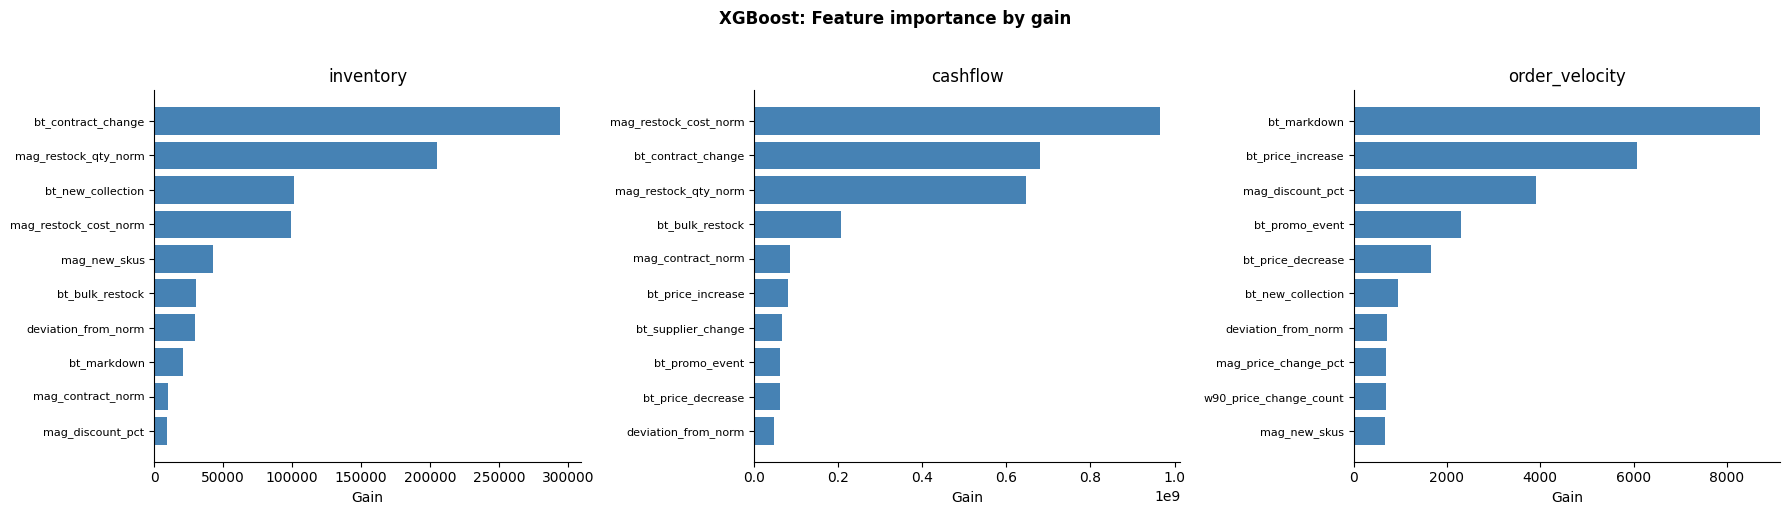

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (target, r) in zip(axes, results.items()):
    scores = r['model_point'].get_booster().get_score(importance_type='gain')
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:10]
    feats, gains = zip(*ranked) if ranked else ([], [])
    ax.barh(range(len(feats)), gains, color='steelblue')
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels([f.replace('label_','') for f in feats], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Gain')
    short = target.replace('label_','').replace('_delta','')
    ax.set_title(short)
plt.suptitle('XGBoost: Feature importance by gain', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


## Predicted vs actual

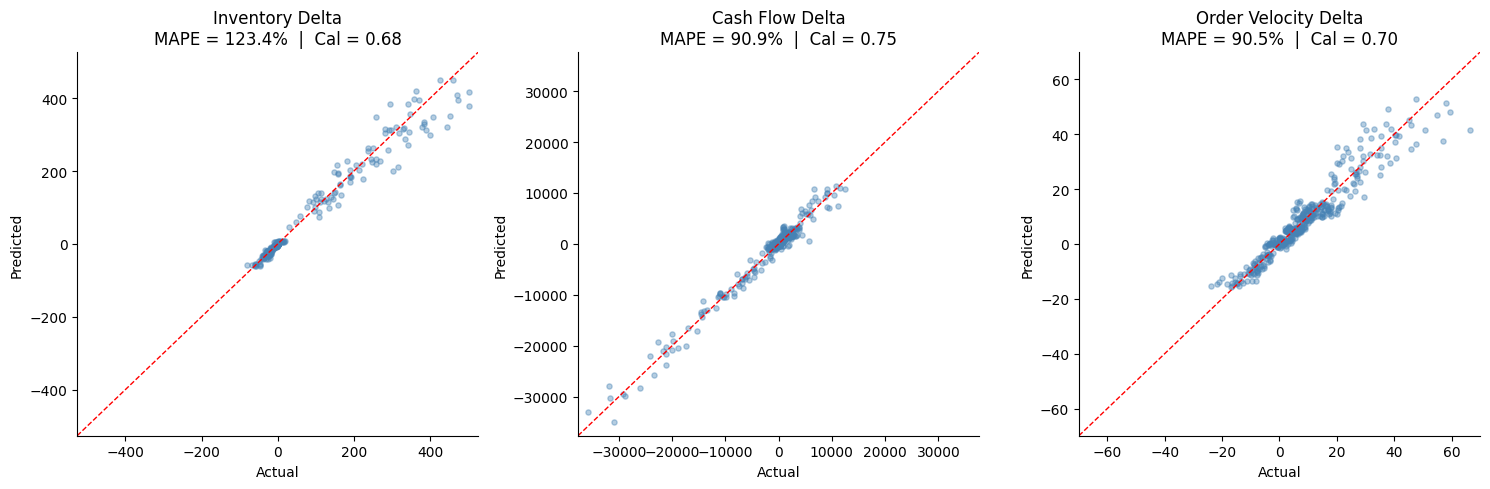

In [5]:
labels = {
    'label_inventory_delta':      'Inventory Delta',
    'label_cashflow_delta':       'Cash Flow Delta',
    'label_order_velocity_delta': 'Order Velocity Delta',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (target, r) in zip(axes, results.items()):
    ax.scatter(r['y_test'], r['y_pred'], alpha=0.4, s=14, color='steelblue')
    lim = max(np.abs(r['y_test']).max(), np.abs(r['y_pred']).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f"{labels[target]}\nMAPE = {r['mape']:.1f}%  |  Cal = {r['calibration']:.2f}")
plt.tight_layout()
plt.show()


## Prediction intervals — sample of 60 test points
Intervals come from quantile XGBoost (α=0.10 / 0.90) trained jointly.

In [ ]:
N = 60
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (target, r) in zip(axes, results.items()):
    idx    = np.argsort(r['y_pred'])[:N]
    pred   = r['y_pred'][idx]
    actual = r['y_test'][idx]
    lower  = r['y_lower'][idx]
    upper  = r['y_upper'][idx]
    yerr   = [np.maximum(pred - lower, 0), np.maximum(upper - pred, 0)]
    ax.errorbar(range(N), pred, yerr=yerr, fmt='none',
                ecolor='#aec6e8', elinewidth=1.2, capsize=0)
    ax.scatter(range(N), actual, s=12, color='steelblue', zorder=3, label='actual')
    ax.scatter(range(N), pred,   s=12, color='darkorange', zorder=3,
               label='predicted', marker='+')
    ax.set_xlabel('Test sample (sorted by prediction)')
    ax.set_ylabel('Value')
    ax.set_title(labels[target].replace(' Delta', ''))
    ax.legend(fontsize=8)
plt.suptitle('XGBoost: 80% prediction intervals (sample)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
